In [1]:
import h5py
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# BNT matrix

In [2]:
M = np.array([[ 1.        ,  0.        ,  0.        ,  0.        ],
              [-1.        ,  1.        ,  0.        ,  0.        ],
              [ 0.4521097 , -1.4521097 ,  1.        ,  0.        ],
              [ 0.        ,  0.25127807, -1.251278  ,  1.        ]])

# Load maps

In [3]:
kgs =[]

for i in range(4):
    with h5py.File('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/cosmo_000002/perm_0000/projected_probes_maps_nobaryons512.h5', 'r') as f:
        kgs.append(np.array(f[f'kg/stage3_lensing{i+1}']))

# Apply BNT to the maps

In [4]:
kgs_bnt = M @ kgs

# Power Spectra

In [5]:
def scale_cls(c):
    ells = np.arange(len(c))
    return ells, ells*(ells+1)*c/(np.pi*2)

In [6]:
# No BNT
cls_kg = []
cls_kg_scaled = []
for i in range(4):
    cls_kg.append(hp.alm2cl(hp.map2alm(kgs[i])))
    ells, cls_kg_scaled_ = scale_cls(cls_kg[i])
    cls_kg_scaled.append(cls_kg_scaled_)
cls_kg = np.array(cls_kg)
cls_kg_scaled = np.array(cls_kg_scaled)

# BNT
cls_bnt = []
cls_bnt_scaled = []
for i in range(4):
    cls_bnt.append(hp.alm2cl(hp.map2alm(kgs_bnt[i])))
    ells, cls_bnt_scaled_ = scale_cls(cls_bnt[i])
    cls_bnt_scaled.append(cls_bnt_scaled_)
cls_bnt = np.array(cls_bnt)
cls_bnt_scaled = np.array(cls_bnt_scaled)

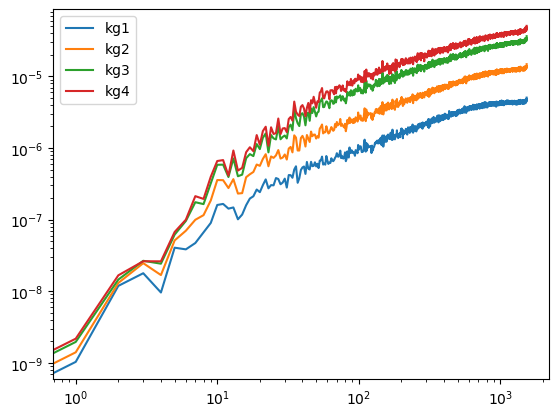

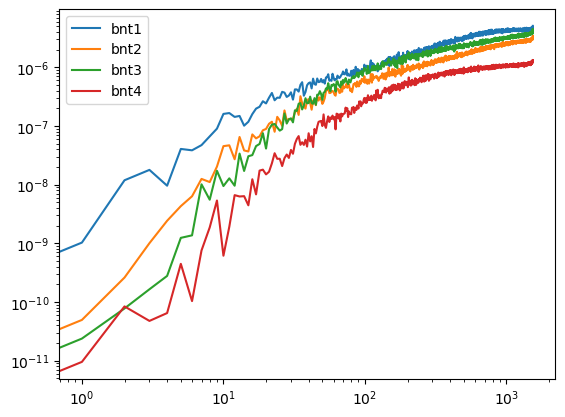

In [7]:
for i in range(4):
    plt.loglog(ells, cls_kg_scaled[i], label=f'kg{i+1}')
plt.legend()
plt.show()

for i in range(4):
    plt.loglog(ells, cls_bnt_scaled[i], label=f'bnt{i+1}')
plt.legend()
plt.show()


## l1-norms

In [2]:
# from pycs.sparsity.mrs.mrs_starlet import *
from pycs.sparsity.mrs.mrs_starlet import mrs_uwttrans

In [3]:
def get_norm_wtl1_sphere(Map, nscales, nbins=None, Mask=None, min_snr=None, max_snr=None, path="/."):
    """
    Computes L1 norms of wavelet transform coefficients at different scales.
    """
    # Set default for nbins if not provided
    if nbins is None:
        nbins = 40

    # Perform undecimated wavelet transform on the spherical map
    WT = mrs_uwttrans(Map, nscale=nscales, verbose=False, path=path)

    # Initialize lists to collect the l1 norm and bins
    l1norm_coll = []
    bins_coll = []

    # Loop through each scale of the wavelet transform
    for i in range(nscales):
        ScaleCoeffs = WT[i]  # Accessing the coefficients for the i-th scale

        # Apply the mask if provided
        if Mask is not None:
            ScaleCoeffs = ScaleCoeffs[Mask != 0]

        # Normalize the wavelet scale to the same energy level
        energy = np.sum(ScaleCoeffs**2)
        normalization_factor = np.sqrt(energy)
        if normalization_factor > 0:
            ScaleCoeffs_normalized = ScaleCoeffs / normalization_factor 
        
        # Set the minimum and maximum values based on inputs or defaults
        min_val = min_snr if min_snr is not None else np.min(ScaleCoeffs_normalized)
        max_val = max_snr if max_snr is not None else np.max(ScaleCoeffs_normalized)

        # Define thresholds and bins
        thresholds = np.linspace(min_val, max_val, nbins + 1)
        bins = 0.5 * (thresholds[:-1] + thresholds[1:])

        # Digitize the values into bins
        digitized = np.digitize(ScaleCoeffs_normalized, thresholds)

        # Calculate the l1 norm for each bin
        bin_l1_norm = [
            np.sum(np.abs(ScaleCoeffs_normalized[digitized == j]))
            for j in range(1, len(thresholds))
        ]

        # Store the bins and l1 norms for this scale
        bins_coll.append(bins)
        l1norm_coll.append(bin_l1_norm)

    # Return the bins and l1 norms for each scale
    return np.array(bins_coll), np.array(l1norm_coll)

In [13]:
_, l1norms = get_norm_wtl1_sphere(kgs[3], 5, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003)
_, l1norms_bnt = get_norm_wtl1_sphere(kgs_bnt[3], 5, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003)

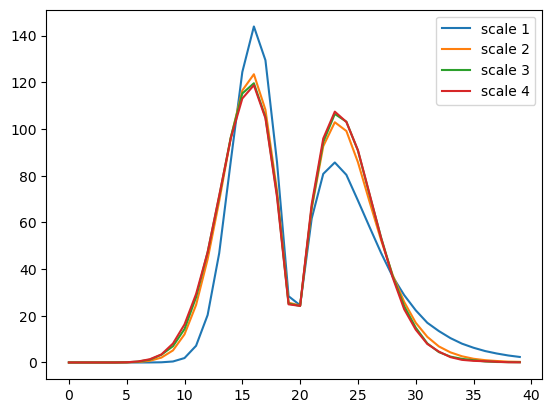

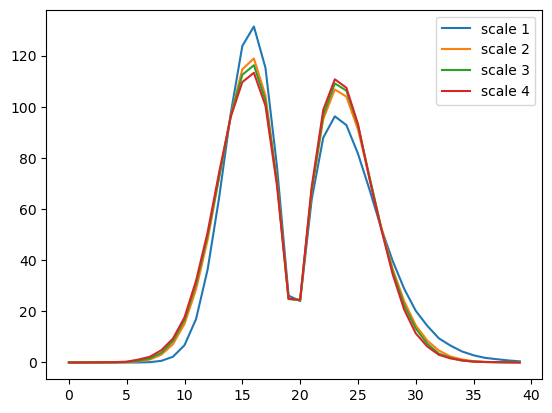

In [14]:
for i in range(4):
    plt.plot(l1norms[i], label=f'scale {i+1}')
plt.legend()
plt.show()

for i in range(4):
    plt.plot(l1norms_bnt[i], label=f'scale {i+1}')
plt.legend()
plt.show()

# Scripts

In [5]:
# BNT matrix
M = np.array([[ 1.        ,  0.        ,  0.        ,  0.        ],
              [-1.        ,  1.        ,  0.        ,  0.        ],
              [ 0.4521097 , -1.4521097 ,  1.        ,  0.        ],
              [ 0.        ,  0.25127807, -1.251278  ,  1.        ]])
# Load maps
kgs =[]

for i in range(4):
    with h5py.File('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/cosmo_000002/perm_0000/projected_probes_maps_nobaryons512.h5', 'r') as f:
        kgs.append(np.array(f[f'kg/stage3_lensing{i+1}']))

# Apply BNT to the maps
kgs_bnt = M @ kgs


## l1-norm

# _, l1norms = get_norm_wtl1_sphere(kgs[3], 5, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003)
_, l1norms_bnt = get_norm_wtl1_sphere(kgs_bnt[3], 5, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003)


In [4]:

kgs =[]

for i in range(4):
    with h5py.File('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/cosmo_000002/perm_0000/projected_probes_maps_nobaryons512.h5', 'r') as f:
        kgs.append(np.array(f[f'kg/stage3_lensing{i+1}']))


## l1-norm

_, l1norms = get_norm_wtl1_sphere(kgs[3], 5, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003)
# _, l1norms_bnt = get_norm_wtl1_sphere(kgs_bnt[3], 5, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003)

In [6]:
with h5py.File('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/cosmo_000002/perm_0000/projected_probes_maps_nobaryons512.h5', "r") as f:
            kg = np.array(f["kg/stage3_lensing4"])  # Extract kappa map

_, l1norms = get_norm_wtl1_sphere(kg, 5, nbins=None, Mask=None, min_snr=-0.003, max_snr=0.003)